<a href="https://colab.research.google.com/github/aishruban5566-ctrl/mlt-programs/blob/main/Untitled1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Mounted at /content/drive


/usr/local/lib/python3.12/dist-packages/matplotlib/cbook.py:1709: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/usr/local/lib/python3.12/dist-packages/matplotlib/cbook.py:1345: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


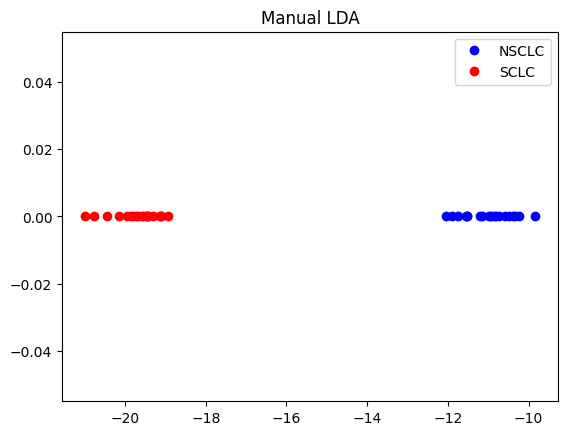

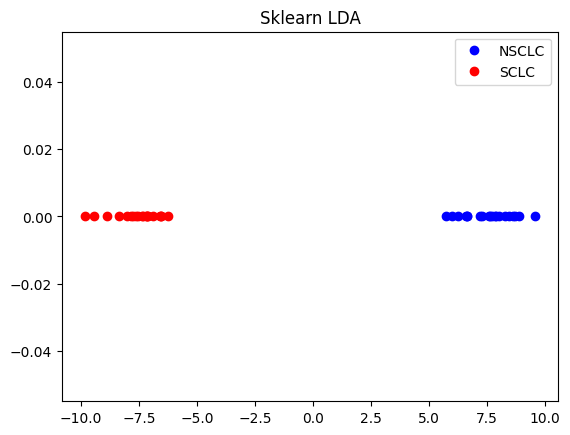

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from numpy import linalg as lg
%matplotlib inline

# Load dataset
df = pd.read_csv('/content/drive/MyDrive/iris1.csv', header=None)
df = df.drop(df.index[0])  # Remove header if present in data
df = df.drop(df.columns[0], axis=1)  # Drop first column (e.g., index column)

X = df.values.astype(float)
num_features = X.shape[1]

# Split data
X1 = X[0:20, :]
X2 = X[20:, :]

# Compute means
m1 = X1.mean(axis=0)
m2 = X2.mean(axis=0)
mean_all = X.mean(axis=0)

# Compute Within-Class Scatter Matrix
S1 = (X1 - m1).T @ (X1 - m1)
S2 = (X2 - m2).T @ (X2 - m2)
S_W = S1 + S2

# Compute Between-Class Scatter Matrix
S_B = 20 * np.outer((m1 - mean_all), (m1 - mean_all)) + \
      20 * np.outer((m2 - mean_all), (m2 - mean_all))

e_val, e_vec = np.linalg.eig(np.linalg.inv(S_W) @ S_B)

# FIX GOES HERE
eig_pairs = [(np.abs(e_val[i]), e_vec[:, i]) for i in range(len(e_val))]
eig_pairs = sorted(eig_pairs, key=lambda x: x[0], reverse=True)

# Project to 1D
W = eig_pairs[0][1].reshape(num_features, 1)
lda_project = X @ W

# Plot manual LDA
plt.figure()
plt.title("Manual LDA")
plt.plot(lda_project[0:20], np.zeros(20), 'bo', label='NSCLC')
plt.plot(lda_project[20:], np.zeros(20), 'ro', label='SCLC')
plt.legend()
plt.show()

# ===========================
# SKLEARN LDA Implementation
# ===========================

from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA

# Labels: 1 for NSCLC, 2 for SCLC
y = np.array([1]*20 + [2]*20)

# Fit and transform
sklearn_lda = LDA(n_components=1)
X_lda_sklearn = sklearn_lda.fit_transform(X, y)
X_lda_sklearn = -X_lda_sklearn  # Optional: flip direction for consistency

# Plot sklearn LDA
plt.figure()
plt.title("Sklearn LDA")
plt.plot(X_lda_sklearn[0:20], np.zeros(20), 'bo', label='NSCLC')
plt.plot(X_lda_sklearn[20:], np.zeros(20), 'ro', label='SCLC')
plt.legend()
plt.show()